# CLASIFICACIÓN DE CLIENTES DE ALTO VALOR — TIENDA AURELION

- Definir el objetivo

Clasificar clientes en dos grupos:

1 → Alto valor

0 → No alto valor

Clasificar si un cliente es de alto valor (1) o no (0) según su historial de compras, con el fin de activar estrategias de fidelización y priorización comercial.

- Preparar los datos

In [1]:
import pandas as pd

# Cargar datos limpios
clientes = pd.read_csv('clientes_limpio.csv')
ventas = pd.read_csv('ventas_limpio.csv')
detalle = pd.read_csv('detalle_ventas_limpio.csv')

# Unificar tablas
ventas_detalle = pd.merge(ventas, detalle, on='id_venta')
ventas_clientes = pd.merge(ventas_detalle, clientes, on='id_cliente')

# Agrupar por cliente
df_clientes = ventas_clientes.groupby('id_cliente').agg({
    'importe': 'sum',
    'id_venta': 'count',
    'cantidad': 'sum'
}).reset_index()

df_clientes.rename(columns={
    'importe': 'LTV',
    'id_venta': 'frecuencia_compra',
    'cantidad': 'total_items'
}, inplace=True)

# Ticket promedio
df_clientes['ticket_promedio'] = df_clientes['LTV'] / df_clientes['frecuencia_compra']


- Etiquetar clientes de alto valor

In [2]:
# Definir umbral (ejemplo: percentil 75 del LTV)
umbral = df_clientes['LTV'].quantile(0.75)
df_clientes['alto_valor'] = (df_clientes['LTV'] > umbral).astype(int)


- División train/test

In [3]:
from sklearn.model_selection import train_test_split

X = df_clientes[['frecuencia_compra', 'ticket_promedio', 'total_items']]
y = df_clientes['alto_valor']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


- Entrenamiento con Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()
modelo.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


- Predicciones y evaluación

Accuracy: 1.0
Matriz de confusión:
 [[14  0]
 [ 0  7]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         7

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



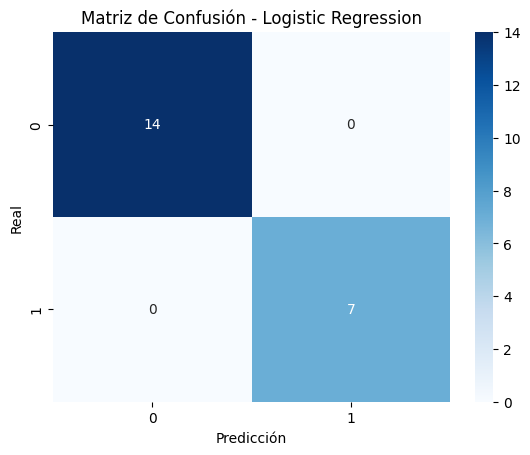

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# Visualización
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


- Validar si el modelo es confiable

In [6]:
modelo = LogisticRegression(max_iter=500)


from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_scaled = escalador.fit_transform(X)

# Usar X_scaled en lugar de X
scores = cross_val_score(modelo, X_scaled, y, cv=5)


from sklearn.model_selection import cross_val_score
scores = cross_val_score(modelo, X, y, cv=5)
print("Accuracy promedio:", scores.mean())


NameError: name 'cross_val_score' is not defined

In [ ]:
# Crear DataFrame con resultados del conjunto de prueba
df_resultados = X_test.copy()

# Añadir id_cliente desde el índice original
df_resultados['id_cliente'] = y_test.index

# Añadir etiquetas reales y predicciones
df_resultados['real'] = y_test.values
df_resultados['predicho'] = y_pred

# Filtrar los que el modelo clasificó como alto valor (predicho = 1)
clientes_predichos_alto_valor = df_resultados[df_resultados['predicho'] == 1]

# Mostrar todos los clientes clasificados como alto valor
clientes_predichos_alto_valor





,frecuencia_compra,ticket_promedio,total_items,id_cliente,real,predicho
36,13,5486.230769,32.0,36,1,1
61,8,7173.250000,21.0,61,1,1
5,5,12300.600000,19.0,5,1,1
0,9,8049.777778,26.0,0,1,1
41,10,9070.100000,31.0,41,1,1
30,8,8089.500000,26.0,30,1,1
54,10,6450.200000,28.0,54,1,1


In [ ]:
# Filtrar clientes con etiqueta 1 (alto valor)
clientes_alto_valor = df_clientes[df_clientes['alto_valor'] == 1]

# Mostrar los  registros
print(clientes_alto_valor)

    id_cliente       LTV  frecuencia_compra  total_items  ticket_promedio  \
0            1   72448.0                  9         26.0      8049.777778   
3            5  132158.0                 15         50.0      8810.533333   
5            8   61503.0                  5         19.0     12300.600000   
19          25   81830.0                  9         30.0      9092.222222   
26          34   57287.0                  5         19.0     11457.400000   
29          39   64786.0                  9         25.0      7198.444444   
30          40   64716.0                  8         26.0      8089.500000   
32          42   60317.0                  9         24.0      6701.888889   
36          49   71321.0                 13         32.0      5486.230769   
38          52   90522.0                 11         29.0      8229.272727   
41          56   90701.0                 10         31.0      9070.100000   
44          61   67959.0                  5         19.0     13591.800000   